# VeryCloudy — Basic Analysis

All plotting logic lives in `src/verycloudy/analysis.py`.  
This notebook only loads data, calls functions, and displays results.

**To switch between testset and full dataset:** change the import in cell 0 between  
`FILEPATH_FULL_TESTSET` (default, small) and `FILEPATH_FULL` (production).

In [56]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt

from verycloudy.analysis import (
    # Overview & data quality
    data_quality_report,
    summary_table,
    rows_per_year,
    # Geographic
    top_countries_bar,
    # Cloud types
    cloud_type_bar,
    subtype_bar,
    cooccurrence_heatmap,
    cooccurrence_cloudtype_subtype,
    # Time
    cloud_by_hour,
    # Weather distributions
    make_quality_df,
    weather_histograms_interactive,
    boxplots_interactive,
    dew_spread_by_altitude,
    # Cloud type vs weather — scatter plots
    scatter_temp_dew_cloudy
)
from verycloudy.styling import standard_style
from verycloudy.config import FILEPATH_DATASET_TO_SHARE

standard_style()

# Load the combined dataset (cloud rows + no-cloud rows merged into one file)
df = pd.read_csv(FILEPATH_DATASET_TO_SHARE, low_memory=False)
print(f"Loaded {len(df)} rows, {df.columns.tolist()}")

Loaded 31188 rows, ['lightbox_id', 'image_url', 'date_iso', 'date_raw', 'author_name', 'author_profile', 'title', 'tags', 'status', 'date_taken', 'time_taken', 'date_taken_utc_xmp', 'time_taken_utc_xmp', 'datetime_source', 'fallback_dt_used', 'datetime_capture', 'city', 'region', 'country', 'latitude', 'longitude', 'location_source', 'dt_unix', 'date_taken_utc', 'time_taken_utc', 'temp', 'feels_like', 'pressure', 'humidity', 'dew_point', 'clouds', 'clouds_low', 'clouds_mid', 'clouds_high', 'wind_speed', 'wind_deg', 'wind_gust', 'visibility', 'weather_code', 'rain_1h', 'snow_1h', 'uvi', 'cloud_type1', 'cloud_type2', 'cloud_type3', 'subtype1', 'subtype2', 'is_cloudy', 'cloud_type_fix']


---
## 1. Dataset overview

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31188 entries, 0 to 31187
Data columns (total 49 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   lightbox_id         31188 non-null  object 
 1   image_url           28687 non-null  object 
 2   date_iso            28688 non-null  object 
 3   date_raw            28688 non-null  object 
 4   author_name         28688 non-null  object 
 5   author_profile      28688 non-null  object 
 6   title               28554 non-null  object 
 7   tags                28688 non-null  object 
 8   status              28688 non-null  float64
 9   date_taken          31188 non-null  object 
 10  time_taken          31188 non-null  object 
 11  date_taken_utc_xmp  1 non-null      object 
 12  time_taken_utc_xmp  1 non-null      object 
 13  datetime_source     11845 non-null  object 
 14  fallback_dt_used    28688 non-null  float64
 15  datetime_capture    28688 non-null  object 
 16  city

In [59]:
display(summary_table(df))

,metric,count,missing,pct
0,total rows,31188,,
1,date range start,1980-01-01,,
2,date range end,2026-03-28,,
3,unique countries,169,,
4,unique locations,11350,,
5,date taken,31188,0,100.0
6,time taken,31188,0,100.0
7,temp,29786,1402,95.5
8,latitude,29788,1400,95.5
9,longitude,29788,1400,95.5


In [63]:
# Data quality summary — verifies key counts and flags anomalies
display(data_quality_report(df))

,check,count,note
0,Total rows,31188,
1,→ cloud photo rows (is_cloudy ≠ False),28688,
2,→ no-cloud rows (is_cloudy = False),2500,no photo datetime — always included in quality_df
3,Rows without weather info,1402,4.5% of all rows
4,→ also no location,1400,weather lookup impossible
5,→ have location but no weather,2,likely too old for archive
6,is_cloudy=True AND cloud cover=0,3506,weather API anomaly; excluded from weather charts
7,→ used fallback time 11:00,2408,time unknown → wrong hour sent to API
8,Rows with date year = 1980,4,outlier; excluded from all charts
9,── Datetime source (cloud photos only) ──,,


In [64]:
nocloudclassification_df = df[
    df["cloud_type1"].isna() & 
    df["subtype1"].isna() &
    df["is_cloudy"]
]

cols = ["lightbox_id", "title", "tags", "date_taken", "time_taken"]
nocloudclassification_df[cols].head(10)

,lightbox_id,title,tags,date_taken,time_taken
228,671031,Northern Lights (Aurora Borealis) spotted near...,"A classic example, At night, Northern/Southern...",2025-11-11,21:40:03
382,668375,Northern Lights (Aurora Borealis) over Brighto...,"A classic example, At night, Northern/Southern...",2025-11-16,11:00:00
1315,653022,The joy Charlotte felt was palpable when she r...,Northern/Southern Lights,2024-10-10,22:02:15
1859,645794,"Anti-crepuscular rays near Baltimore, Maryland...","Sunset / Sunrise, Crepuscular rays & shadows",2019-09-20,19:32:32
2252,640146,A faint red aurora borealis spotted over Crank...,"At night, Northern/Southern Lights",2025-03-26,20:15:06
2312,639253,"Rainbow over Kew, Australia","App Photo of the Day, Rainbow",2025-03-19,11:00:00
2323,639136,"Fallstreak Hole over Gulangyu, China",App Photo of the Day,2025-03-18,11:00:00
2331,639039,"Corona over Lochbuie, United States","Corona, App Photo of the Day",2025-03-17,11:00:00
2366,638627,"Sun Pillar over Oberndorf, Germany","App Photo of the Day, Sun pillar",2025-03-13,11:00:00
2389,638384,"Kelvin-Helmholtz over Langeraar, The Netherlands",App Photo of the Day,2025-03-11,11:00:00


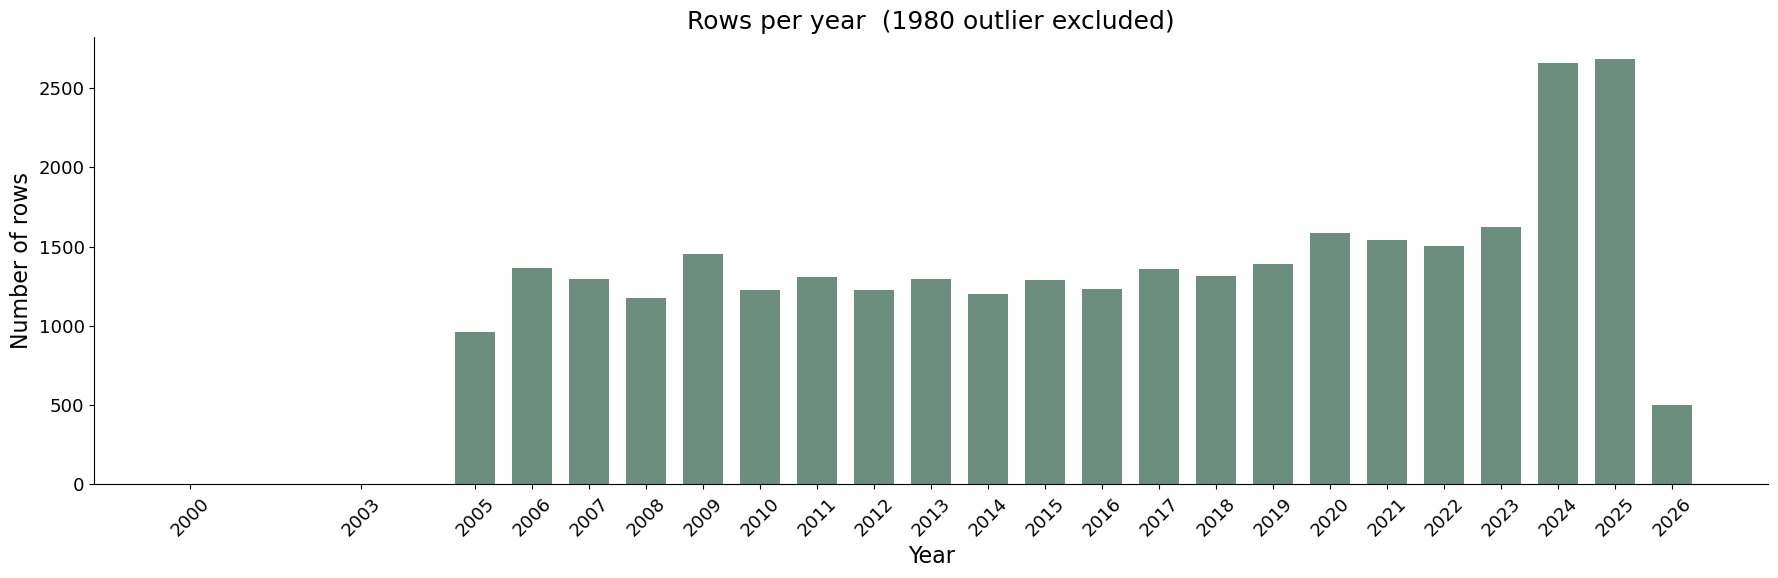

In [30]:
fig = rows_per_year(df)
plt.show()

---
## 2. Geographic spread

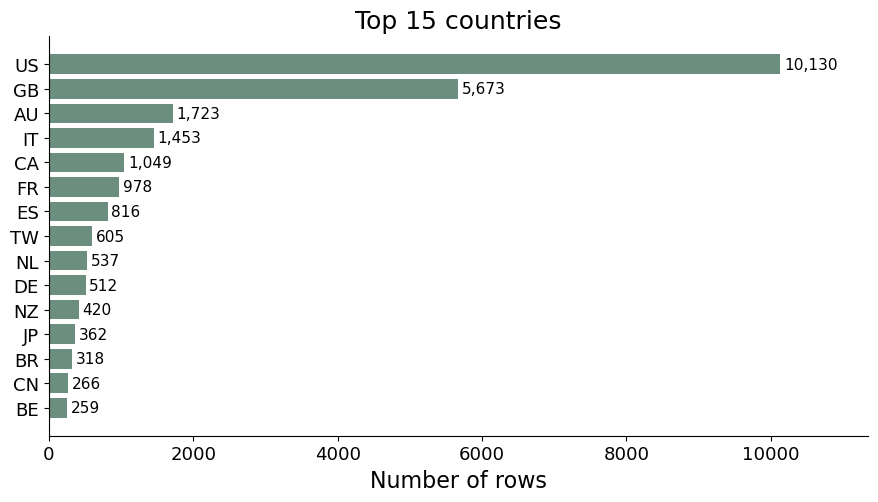

In [31]:
fig = top_countries_bar(df, n=15)
plt.show()

---
## 3. Cloud types

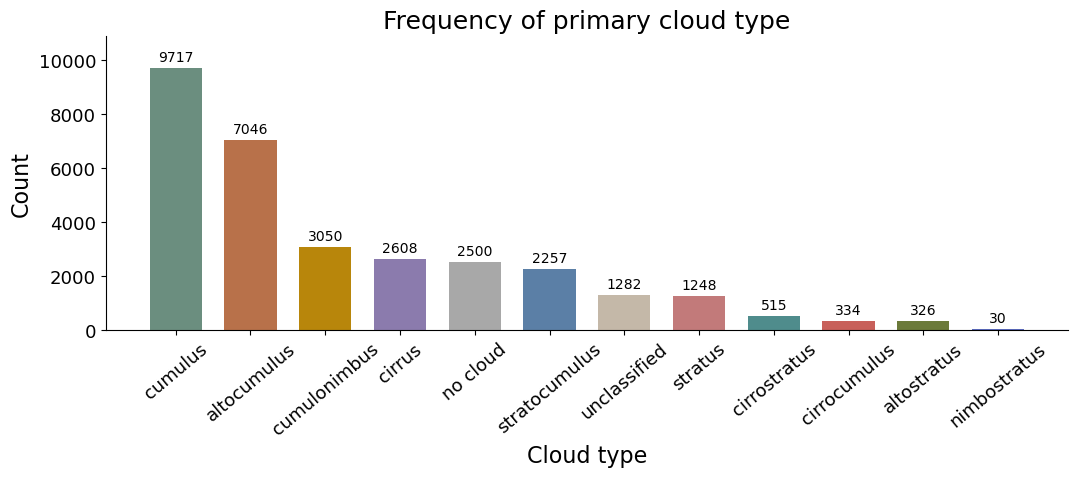

In [32]:
fig = cloud_type_bar(df)
plt.show()

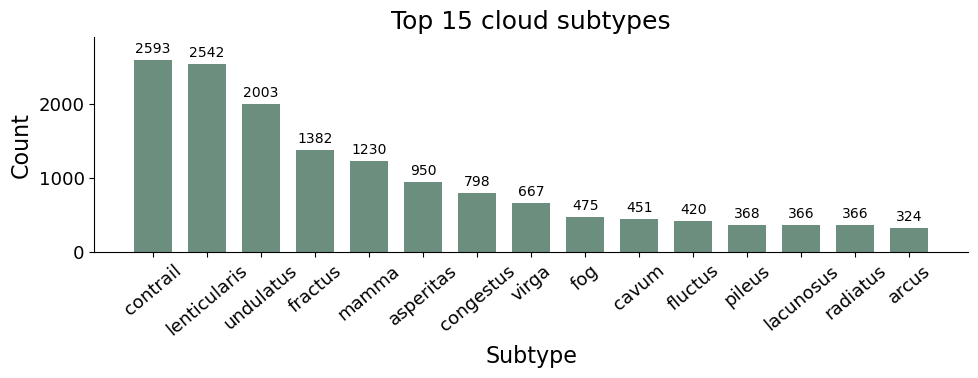

In [33]:
fig = subtype_bar(df, n=15)
plt.show()

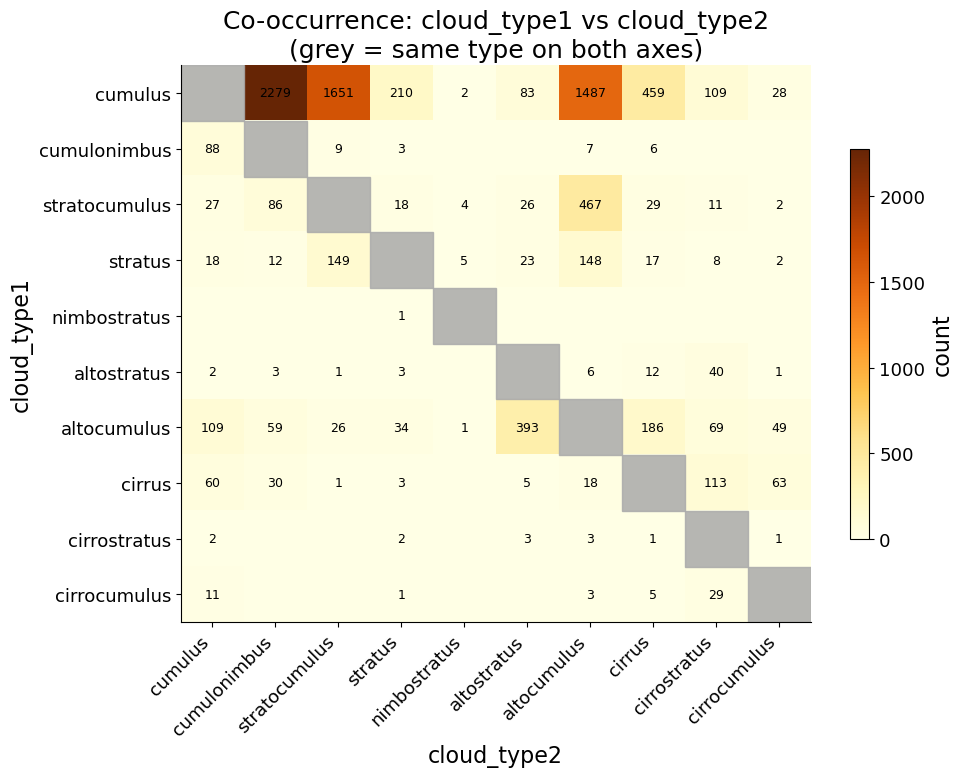

In [34]:
# Co-occurrence: cloud_type1 vs cloud_type2 (grey diagonal = same type on both axes)
fig = cooccurrence_heatmap(df)
plt.show()

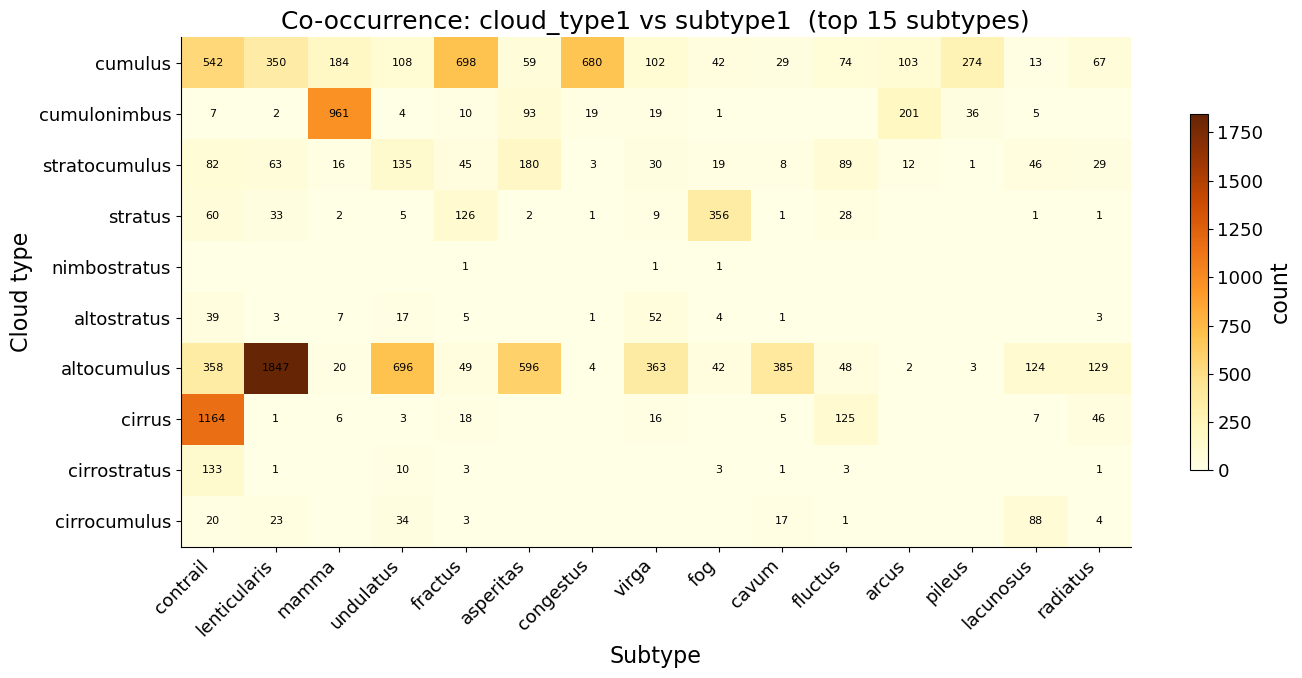

In [35]:
# Co-occurrence: cloud_type1 vs top 15 subtypes
fig = cooccurrence_cloudtype_subtype(df)
plt.show()

---
## 4. Cloud observations by hour of day
Rows where fallback time 11:00 was used are excluded (time is unknown for those rows).  
Use the dropdown to filter by cloud type or by month.

C:\Users\karen\AppData\Local\Temp\ipykernel_29964\3299996873.py:2: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



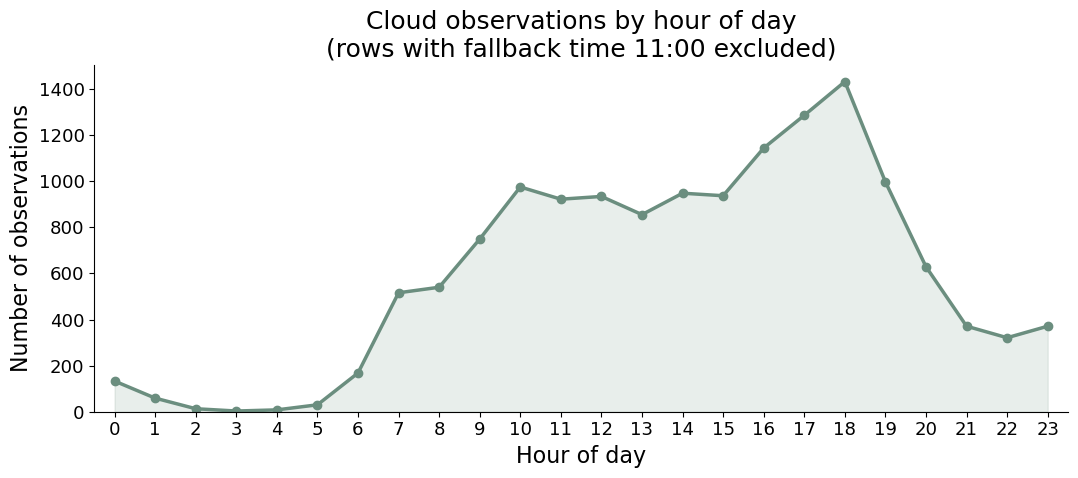

In [36]:
fig = cloud_by_hour(df)
fig.show()

In [45]:
quality_df = make_quality_df(df)

In [52]:
# Interactive: choose weather variable from dropdown
weather_histograms_interactive(quality_df)
plt.show()

interactive(children=(Dropdown(description='Variable:', options=(('Temperature (°C)', 'temp'), ('Humidity (%)'…

In [53]:
# Interactive box plots: choose weather variable from dropdown
boxplots_interactive(quality_df)
plt.show()

interactive(children=(Dropdown(description='Variable:', options=(('Temperature (°C)', 'temp'), ('Humidity (%)'…

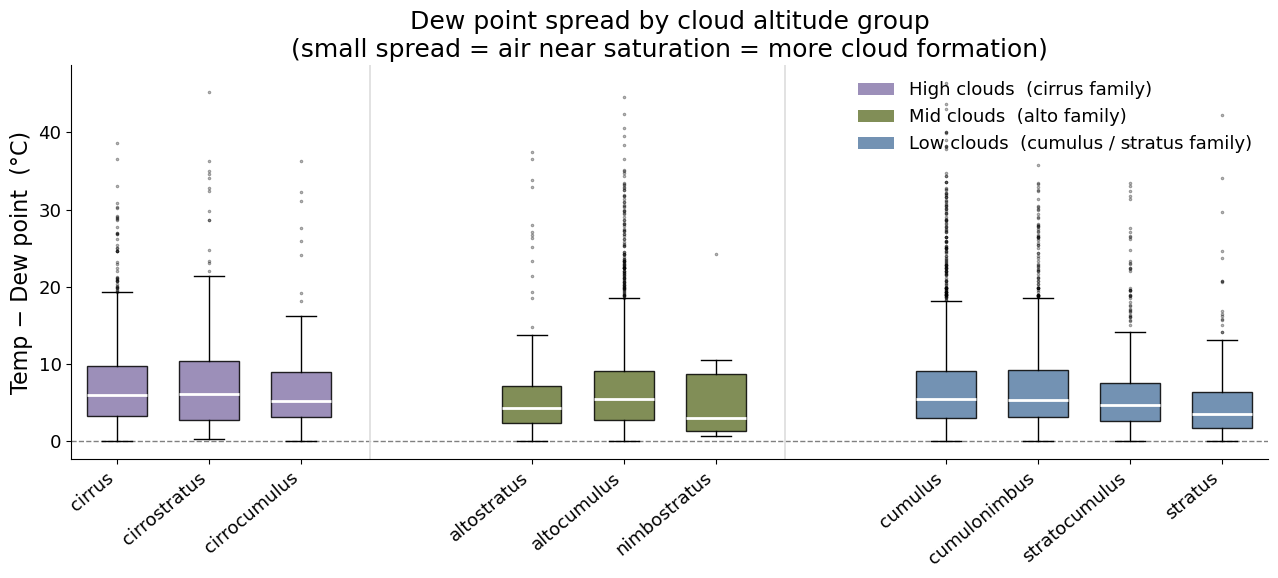

In [54]:
# Dew point spread grouped by altitude level: high / mid / low cloud families
dew_spread_by_altitude(quality_df)
plt.show()

---
## 6. Cloud type vs weather

These charts are designed to show the meteorological signal behind each cloud type —
useful for the oral exam and as motivation for the ML model features.

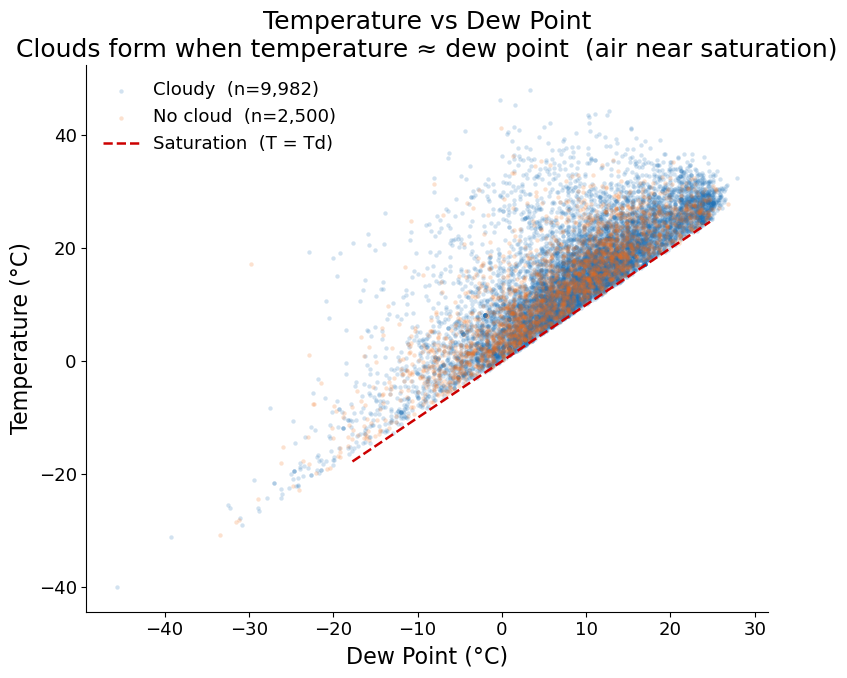

In [55]:
scatter_temp_dew_cloudy(quality_df)
plt.show()